# **Taylor**

In [67]:
import math
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List

In [68]:
def TaylorSerie(x0: float, fn: sp.Function, n: int, x: sp.Symbol) -> sp.Function:
  pol = 0
  for k in range(n+1):
    fn_diff = sp.diff(fn, x, k)
    pol += (fn_diff.subs(x, x0)/math.factorial(k)) * ((x-x0)**k)

  return sp.expand(pol)


In [69]:
def EvalFunction(pol: sp.Function, x: sp.Symbol, values: List[float]) -> List[float]:
  fn = sp.lambdify(x, pol, 'numpy')
  return fn(values)

In [70]:
def FunctionMetrics(fn: sp.Function, pol: sp.Function, x: sp.Symbol, values: List[float]) -> pd.DataFrame:
    f = np.asarray(sp.lambdify(x, fn, 'numpy')(values))
    p = np.asarray(sp.lambdify(x, pol, 'numpy')(values))

    e_abs = np.abs(f - p)
    e_rel = np.abs(e_abs / f)

    return pd.DataFrame({
        'x': values,
        'valor verdadero': f,
        'valor aprox': p,
        'e_absoluto': e_abs,
        'e_relativo': e_rel
    })


In [71]:
def PlotFunction(fn: sp.Function, pol: sp.Function, x0: float, x: sp.Symbol, delta: float, num_points: int = 1000) -> None:
  f = sp.lambdify(x, fn, 'numpy')
  p = sp.lambdify(x, pol, 'numpy')

  x_values = np.linspace(x0-delta, x0+2*delta, num_points)
  plt.plot(x_values, f(x_values), 'r', label='f(x)')
  plt.plot(x_values, p(x_values), 'b', label='p(x)')
  plt.xlabel('Eje X')
  plt.ylabel('Eje Y')
  plt.legend()
  plt.grid()

  return None

In [72]:
def TruncationLevel(fn: sp.Function, n: int, x0: float, x_value: float, x, num_points: int = 1000):
  fn_diff = sp.lambdify(x, sp.diff(fn, x, n+1))
  mini, maxi = min(x0, x_value), max(x0, x_value)
  x_points = np.linspace(mini, maxi, num_points)

  e = max(abs(fn_diff(x_points)))
  return e * abs(x_value - x0)**(n+1)/math.factorial(n+1)

# Ejercicio

Calcular el polinomio de grado 2 para la función $f(x)=e^{x}\sin (x)$ entonco a $x_0=0$. Hallar
1. P(0.5), P(4), P(4.5)
2. Determine la cota del error $R_2(0.5)$
3. Realice una grafica del polinomio construido versus la función
4. Determine una aproximación para $f'(0.5)$
5. Determine una aproximación para $\int_{0}^{0.5} f(x)dx $

In [73]:
x = sp.symbols('x')
fn = sp.exp(x) * sp.sin(x)
pol = TaylorSerie(0, fn, 2, x)
values = np.array([0.5, 4, 4.5])

In [74]:
FunctionMetrics(fn, pol, x, values)

,x,valor verdadero,valor aprox,e_absoluto,e_relativo
0,0.5,0.790439,0.75,0.040439,0.051160
1,4.0,-41.320016,20.00,61.320016,1.484027
2,4.5,-87.994457,24.75,112.744457,1.281268


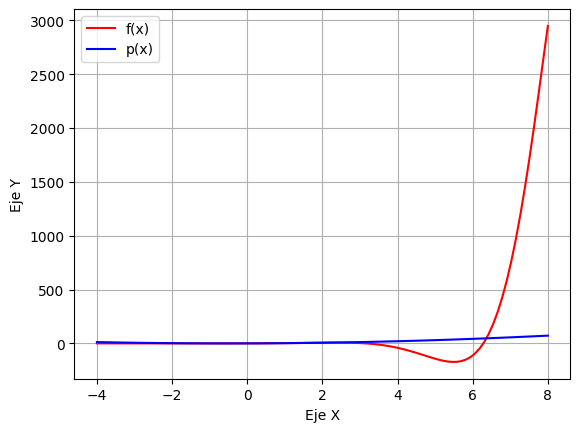

In [75]:
PlotFunction(fn, pol, 0, x, 4, 100)

In [76]:
sp.diff(fn, x, 3).subs(x, 0)

2

In [77]:
TruncationLevel(fn, 2, 0, 0.5, x, 1000)

np.float64(0.041666666666666664)

Sea $f(x)=\displaystyle \frac{e^{x}}{x}$ y $x_0=1$.
- Determine el polinomio de taylor $P_n(x)$ para $f(x)$ en torno a $x_0$ y error, donde el grado del polinomio es $n=8$.
- Aproxime $f(0.5)$, $f(1.5)$, $f(10)$
- Determine la cota del error al aproximar con $p_8(0.1)$ a $f(0.1)$(use la fórmula del error de Taylor),
- Aproxime $\displaystyle \int_{0.5}^{1}f(x)dx$
- Aproxime $\displaystyle f'(0.5)dx$
- Que pasa si en vez de construir un polinomio de grado 8, le aumentamos términos a la serie de Taylor para aproximar  $f(10)$
-  Realice una gráfica de la función  $f(x)$  y el polinomio


In [78]:
x = sp.symbols('x')
fn = sp.exp(x)/x
x0 = 1
n = 10

pol = TaylorSerie(x0, fn, n, x)
pol

16481*E*x**10/44800 - 1468457*E*x**9/362880 + 181291*E*x**8/8960 - 611857*E*x**7/10080 + 2097797*E*x**6/17280 - 815807*E*x**5/4800 + 978989*E*x**4/5760 - 3670679*E*x**3/30240 + 1633267*E*x**2/26880 - 808393*E*x/40320 + 16019531*E/3628800

In [79]:
FunctionMetrics(fn, pol, x, np.array([0.5,1.5,10]))

,x,valor verdadero,valor aprox,e_absoluto,e_relativo
0,0.5,3.297443,3.296466e+00,9.765625e-04,2.961575e-04
1,1.5,2.987793,2.988118e+00,3.255208e-04,1.089503e-04
2,10.0,2202.646579,3.138108e+09,3.138106e+09,1.424698e+06


In [80]:
TruncationLevel(fn, n, x0, 0.1, x)

np.float64(313810596089.9999)

In [81]:
integral = 0
x_points = np.linspace(0.5, 1, 10000)
dx = x_points[1] - x_points[0]

for i in x_points:
  integral += pol.evalf(subs={x: i})*dx

integral

1.44101036070284

In [82]:
der = (pol.evalf(subs={x: 0.5+dx}) - pol.evalf(subs={x: 0.5-dx}))/(2 * dx)

der

-3.27400507677323

In [83]:
sp.diff(fn, x).subs(x, 0.5)

-3.29744254140026

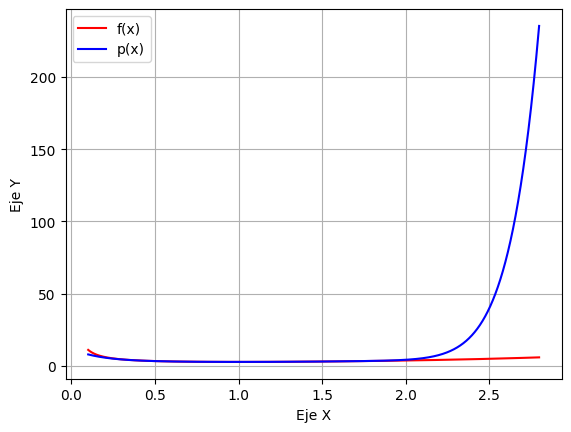

In [84]:
PlotFunction(fn, pol, x0, x, .9, 10000)

# **Biseccion**

In [85]:
def Biseccion(fn, a, b, tol):
  if fn(a)*fn(b) > 0:
    return None

  iters = 0
  while abs(b-a) > tol:
    p = (a+b)/2
    iters += 1
    if abs(fn(p)) < tol:
      return p, iters
    elif fn(a)*fn(p) < 0:
      b = p
    else:
      a = p

  return p, iters

In [86]:
fn = lambda x: x**2 - 7
Biseccion(fn, 2, 3, 1e-6)

(2.6457509994506836, 20)

In [87]:
g = 32.17
x = 1.7

fn=lambda w: -g/(2*w**2)*(np.sinh(w) - np.sin(w)) - x
sol, iters = Biseccion(fn, -0.5, -1e-3, 1e-5)
sol, iters

(-0.3170627746582031, 15)

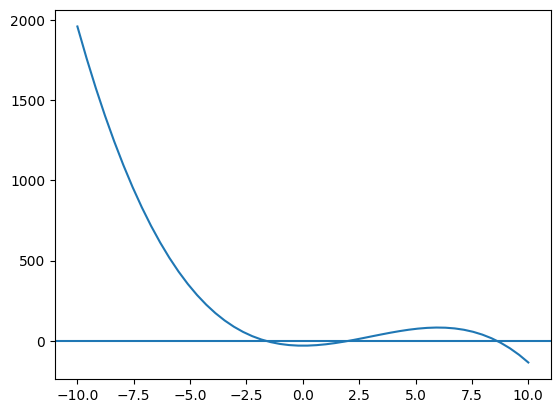

In [88]:
R = 3
V = 30

V_fn = lambda h: (np.pi * h**2)*(3*R - h)/3-V
l = np.linspace(-10, 10)
v = []
for i in l:
  v.append(V_fn(i))

plt.plot(l, v)
plt.axhline(0)

In [89]:
Biseccion(V_fn, 0, 6.0, 1e-6)

(2.0269052982330322, 23)

# Ejercicio 4:

  ¿La suma de dos números es 20. Si a cada uno se le suma su raíz cuadrada, el producto de las dos sumas es de 155.55. Determine los dos números con una exactitud de $10^{-6}$?

/tmp/ipykernel_517/2270594238.py:1: RuntimeWarning: invalid value encountered in sqrt
  fn_4 = lambda x: (x + np.sqrt(x))*(20 - x + np.sqrt(20 - x)) - 155.55


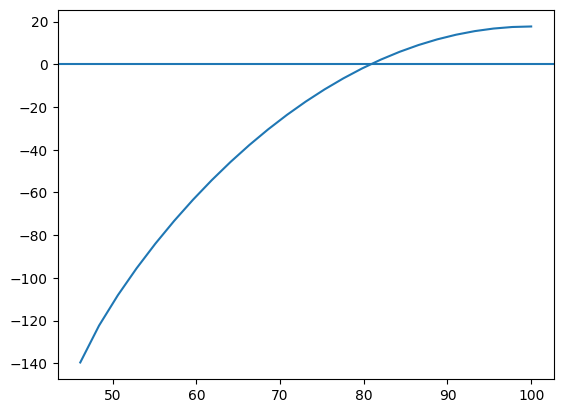

In [90]:
fn_4 = lambda x: (x + np.sqrt(x))*(20 - x + np.sqrt(20 - x)) - 155.55

x_p = np.linspace(-10, 100)
r_p = []
for i in l:
  r_p.append(fn_4(i))

plt.axhline(0)
plt.plot(x_p, r_p)

In [91]:
x, _ = Biseccion(fn_4, 6, 8, 1e-5)
y = 20 - x

x, y

(6.512847900390625, 13.487152099609375)

In [92]:
(x + np.sqrt(x))*(y + np.sqrt(y))

np.float64(155.5499915590526)